In [2]:
# Imports + BBC data preparation for BERT base
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from transformers import AutoTokenizer

_ROOT = Path("..").resolve()
_SRC = _ROOT / "src"
if str(_SRC) not in sys.path:
    sys.path.insert(0, str(_SRC))

from llm_doc_classification.config import (
    bbc_data_dir,
    bert_best_head_weights,
    config_path_display,
    load_config,
)
from llm_doc_classification.data.bbc import (
    BBC_LABELS,
    bbc_label_maps,
    clean_bbc_splits,
    load_bbc_split,
    raw_dataset_dict_from_bbc_frames,
)


In [3]:
# Paths / BERT hyperparams from `configs/default.json` (`bert` section)
_BERT = load_config()["bert"]
DATA_ROOT = bbc_data_dir()
MODEL_NAME = _BERT["model_name"]
MAX_LENGTH = _BERT["max_length"]
print("Config:", config_path_display())
LABELS = list(BBC_LABELS)
label2id, id2label = bbc_label_maps()

train_df = load_bbc_split(DATA_ROOT, "train")
val_df = load_bbc_split(DATA_ROOT, "val")
test_df = load_bbc_split(DATA_ROOT, "test")
train_df, val_df, test_df = clean_bbc_splits(train_df, val_df, test_df, label2id=label2id)

a = len(train_df)
b = len(val_df)
c = len(test_df)
print(f"Train: {a}, Val: {b}, Test: {c}")

raw_datasets = raw_dataset_dict_from_bbc_frames(train_df, val_df, test_df)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


def tokenize_batch(batch):
    return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=MAX_LENGTH)


tokenized_datasets = raw_datasets.map(tokenize_batch, batched=True)
tokenized_datasets = tokenized_datasets.rename_column("label_id", "labels")
tokenized_datasets.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

print(tokenized_datasets)
print("Label mapping:", label2id)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

Loaded train from train.csv (no train/ folder found)
Loaded val from val.csv (no val/ folder found)
Loaded test from test.csv (no test/ folder found)
Train: 1780, Val: 222, Test: 223


Map:   0%|          | 0/1780 [00:00<?, ? examples/s]

Map:   0%|          | 0/222 [00:00<?, ? examples/s]

Map:   0%|          | 0/223 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'label', 'path', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1780
    })
    validation: Dataset({
        features: ['text', 'labels', 'label', 'path', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 222
    })
    test: Dataset({
        features: ['text', 'labels', 'label', 'path', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 223
    })
})
Label mapping: {'business': 0, 'entertainment': 1, 'politics': 2, 'sport': 3, 'tech': 4}
Device: cuda


In [4]:
# Test inference with frozen BertModel + custom CLS head (no training)
import torch.nn as nn
from sklearn.metrics import accuracy_score, classification_report
from torch.utils.data import DataLoader
from transformers import BertModel


class FrozenBertClassifier(nn.Module):
    def __init__(self, model_name: str, num_labels: int):
        super().__init__()
        self.bert = BertModel.from_pretrained(model_name)

        # Freeze all BERT parameters.
        for param in self.bert.parameters():
            param.requires_grad = False

        hidden_size = self.bert.config.hidden_size
        self.classifier = nn.Linear(hidden_size, num_labels)

    def forward(self, input_ids, attention_mask=None, token_type_ids=None):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
        )
        cls_embedding = outputs.last_hidden_state[:, 0, :]
        logits = self.classifier(cls_embedding)
        probs = torch.softmax(logits, dim=-1)
        return logits, probs


# Build model and move to device
num_labels = len(LABELS)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FrozenBertClassifier(MODEL_NAME, num_labels=num_labels).to(device)
model.eval()

# Build DataLoader from BBC test split only
test_dataset = tokenized_datasets["test"]

# Ensure returned batches are torch tensors and include token_type_ids when available.
cols = ["input_ids", "attention_mask", "labels"]
if "token_type_ids" in test_dataset.column_names:
    cols.insert(2, "token_type_ids")
test_dataset.set_format(type="torch", columns=cols)

test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

all_probs = []
all_preds = []
all_true = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        token_type_ids = batch.get("token_type_ids")
        if token_type_ids is not None:
            token_type_ids = token_type_ids.to(device)

        logits, probs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
        )

        preds = torch.argmax(probs, dim=-1)

        all_probs.append(probs.cpu())
        all_preds.append(preds.cpu())
        all_true.append(labels.cpu())

all_probs = torch.cat(all_probs, dim=0).numpy()
all_pred_ids = torch.cat(all_preds, dim=0).numpy()
all_true_ids = torch.cat(all_true, dim=0).numpy()

y_pred = [id2label[int(i)] for i in all_pred_ids]
y_true = [id2label[int(i)] for i in all_true_ids]

acc = accuracy_score(y_true, y_pred)
print(f"Test accuracy (frozen BertModel + random linear head): {acc:.4f}")
print("\nClassification report (test only):")
print(classification_report(y_true, y_pred, labels=LABELS, digits=4))

print("\nProbabilities shape:", all_probs.shape)
print("First sample probabilities:", all_probs[0])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Test accuracy (frozen BertModel + random linear head): 0.2332

Classification report (test only):
               precision    recall  f1-score   support

     business     0.1316    0.0980    0.1124        51
entertainment     0.0000    0.0000    0.0000        39
     politics     0.0000    0.0000    0.0000        42
        sport     0.2733    0.8627    0.4151        51
         tech     0.1429    0.0750    0.0984        40

     accuracy                         0.2332       223
    macro avg     0.1095    0.2072    0.1252       223
 weighted avg     0.1182    0.2332    0.1383       223


Probabilities shape: (223, 5)
First sample probabilities: [0.24053265 0.14677504 0.1326794  0.2808221  0.19919081]


d:\llm_doc_classification\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\llm_doc_classification\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\llm_doc_classification\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


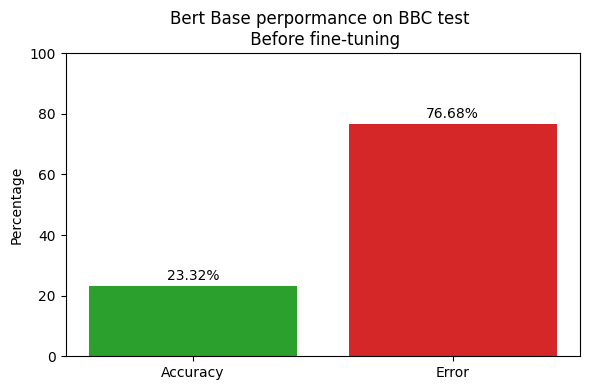

In [5]:
# Visualize BBC test accuracy
import matplotlib.pyplot as plt

if "acc" not in globals():
    raise RuntimeError("Run the previous test-evaluation cell first so `acc` is available.")

accuracy_pct = acc * 100.0
error_pct = (1.0 - acc) * 100.0

plt.figure(figsize=(6, 4))
bars = plt.bar(["Accuracy", "Error"], [accuracy_pct, error_pct], color=["#2ca02c", "#d62728"])
plt.ylim(0, 100)
plt.ylabel("Percentage")
plt.title("Bert Base perpormance on BBC test \n Before fine-tuning")

for bar, value in zip(bars, [accuracy_pct, error_pct]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.tight_layout()
plt.show()

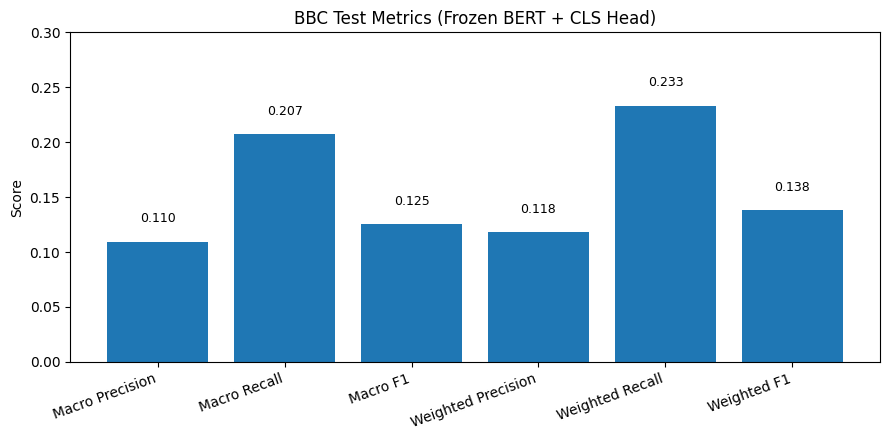

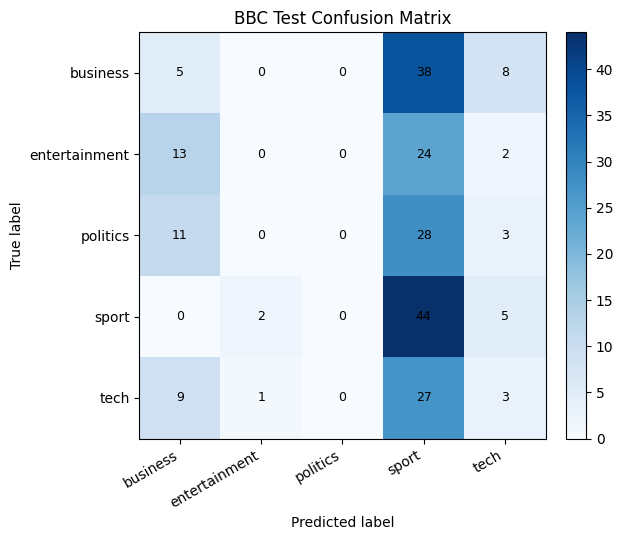

Per-class metrics:
business        P=0.132  R=0.098  F1=0.112
entertainment   P=0.000  R=0.000  F1=0.000
politics        P=0.000  R=0.000  F1=0.000
sport           P=0.273  R=0.863  F1=0.415
tech            P=0.143  R=0.075  F1=0.098


In [6]:
# Visualize additional BBC test metrics (precision/recall/F1 + confusion matrix)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

if "y_true" not in globals() or "y_pred" not in globals():
    raise RuntimeError("Run the previous test-evaluation cell first so `y_true` and `y_pred` are available.")

report = classification_report(y_true, y_pred, labels=LABELS, output_dict=True, zero_division=0)

macro_p = report["macro avg"]["precision"]
macro_r = report["macro avg"]["recall"]
macro_f1 = report["macro avg"]["f1-score"]
weighted_p = report["weighted avg"]["precision"]
weighted_r = report["weighted avg"]["recall"]
weighted_f1 = report["weighted avg"]["f1-score"]

# Figure 1: aggregated metrics
metric_names = [
    "Macro Precision", "Macro Recall", "Macro F1",
    "Weighted Precision", "Weighted Recall", "Weighted F1"
]
metric_values = [macro_p, macro_r, macro_f1, weighted_p, weighted_r, weighted_f1]

plt.figure(figsize=(9, 4.5))
bars = plt.bar(metric_names, metric_values, color="#1f77b4")
plt.ylim(0, 0.3)
plt.ylabel("Score")
plt.title("BBC Test Metrics (Frozen BERT + CLS Head)")
plt.xticks(rotation=20, ha="right")

for bar, value in zip(bars, metric_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.015,
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

# Figure 2: confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=LABELS)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(cm, cmap="Blues")
ax.set_title("BBC Test Confusion Matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_xticks(np.arange(len(LABELS)))
ax.set_yticks(np.arange(len(LABELS)))
ax.set_xticklabels(LABELS, rotation=30, ha="right")
ax.set_yticklabels(LABELS)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="black", fontsize=9)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

print("Per-class metrics:")
for label in LABELS:
    print(
        f"{label:14s}  P={report[label]['precision']:.3f}  R={report[label]['recall']:.3f}  F1={report[label]['f1-score']:.3f}"
    )

In [7]:
# Full BERT fine-tuning only (GPT-2-style monitoring, BERT-appropriate architecture)
import copy
from pathlib import Path
from time import perf_counter

import torch.nn as nn
from sklearn.metrics import accuracy_score
from torch.optim import AdamW
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from transformers import BertModel


class BertClassifier(nn.Module):
    def __init__(self, model_name: str, num_labels: int, dropout_prob: float = 0.1):
        super().__init__()
        self.bert = BertModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout_prob)
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_labels)

    def forward(self, input_ids, attention_mask=None, token_type_ids=None):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
        )
        cls_embedding = outputs.last_hidden_state[:, 0, :]
        cls_embedding = self.dropout(cls_embedding)
        logits = self.classifier(cls_embedding)
        return logits


def format_for_classification(text: str) -> str:
    return f"Text: {text} [SEP] Label:"


def build_prompted_tokenized_datasets():
    prompted = raw_datasets.map(lambda b: {"text": [format_for_classification(t) for t in b["text"]]}, batched=True)

    def tokenize_batch(batch):
        return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=MAX_LENGTH)

    tokenized = prompted.map(tokenize_batch, batched=True)
    tokenized = tokenized.rename_column("label_id", "labels")
    return tokenized


def build_loader(tokenized, split_name: str, batch_size: int, shuffle: bool) -> DataLoader:
    ds = tokenized[split_name]
    cols = ["input_ids", "attention_mask", "labels"]
    if "token_type_ids" in ds.column_names:
        cols.insert(2, "token_type_ids")
    ds.set_format(type="torch", columns=cols)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def evaluate_loss_and_accuracy(model: nn.Module, loader: DataLoader, criterion: nn.Module, device: torch.device):
    model.eval()
    running_loss = 0.0
    all_pred_ids = []
    all_true_ids = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            token_type_ids = batch.get("token_type_ids")
            if token_type_ids is not None:
                token_type_ids = token_type_ids.to(device)

            logits = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids,
            )
            loss = criterion(logits, labels)
            running_loss += loss.item()

            pred_ids = torch.argmax(logits, dim=-1)
            all_pred_ids.append(pred_ids.cpu())
            all_true_ids.append(labels.cpu())

    all_pred_ids = torch.cat(all_pred_ids, dim=0).numpy()
    all_true_ids = torch.cat(all_true_ids, dim=0).numpy()
    avg_loss = running_loss / len(loader)
    acc_local = accuracy_score(all_true_ids, all_pred_ids)
    return avg_loss, acc_local, all_true_ids, all_pred_ids


num_labels = len(LABELS)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
learning_rate = 3e-5
batch_size = 8
num_epochs = 6
patience = 2
best_weights_path = bert_best_head_weights()

prompted_tokenized_datasets = build_prompted_tokenized_datasets()
train_loader = build_loader(prompted_tokenized_datasets, "train", batch_size=batch_size, shuffle=True)
val_loader = build_loader(prompted_tokenized_datasets, "validation", batch_size=batch_size, shuffle=False)

model = BertClassifier(MODEL_NAME, num_labels=num_labels, dropout_prob=0.1).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = AdamW(model.parameters(), lr=learning_rate)

best_val_loss = float("inf")
best_val_acc = -1.0
best_state_dict = None
no_improve_epochs = 0

train_loss_history = []
train_acc_history = []
val_loss_history = []
val_acc_history = []

for epoch in range(1, num_epochs + 1):
    epoch_start = perf_counter()
    if device.type == "cuda":
        torch.cuda.reset_peak_memory_stats(device)

    model.train()
    running_loss = 0.0
    train_correct = 0
    train_total = 0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs}", leave=False)
    for step, batch in enumerate(progress_bar, start=1):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        token_type_ids = batch.get("token_type_ids")
        if token_type_ids is not None:
            token_type_ids = token_type_ids.to(device)

        optimizer.zero_grad()
        logits = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
        )
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = torch.argmax(logits, dim=-1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

        avg_loss_so_far = running_loss / step
        train_acc_so_far = train_correct / train_total
        progress_bar.set_postfix(loss=f"{avg_loss_so_far:.4f}", train_acc=f"{train_acc_so_far:.4f}")

    train_loss = running_loss / len(train_loader)
    train_acc = train_correct / train_total
    val_loss, val_acc, _, _ = evaluate_loss_and_accuracy(model, val_loader, criterion, device)
    epoch_time = perf_counter() - epoch_start

    train_loss_history.append(train_loss)
    train_acc_history.append(train_acc)
    val_loss_history.append(val_loss)
    val_acc_history.append(val_acc)

    print(
        f"Epoch {epoch}/{num_epochs} | train_loss: {train_loss:.4f} | train_acc: {train_acc:.4f} | "
        f"val_loss: {val_loss:.4f} | val_acc: {val_acc:.4f} | time: {epoch_time:.1f}s"
    )

    if device.type == "cuda":
        allocated_gb = torch.cuda.memory_allocated(device) / (1024**3)
        reserved_gb = torch.cuda.memory_reserved(device) / (1024**3)
        peak_allocated_gb = torch.cuda.max_memory_allocated(device) / (1024**3)
        print(
            f"  GPU mem (GB) | allocated: {allocated_gb:.3f} | reserved: {reserved_gb:.3f} | peak_allocated: {peak_allocated_gb:.3f}"
        )
    else:
        print("  GPU mem (GB) | allocated: N/A | reserved: N/A | peak_allocated: N/A (CUDA not available)")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_acc = val_acc
        best_state_dict = copy.deepcopy(model.state_dict())
        torch.save(best_state_dict, best_weights_path)
        no_improve_epochs = 0
        print(f"  Saved new best weights -> {best_weights_path} (val_loss={best_val_loss:.4f}, val_acc={best_val_acc:.4f})")
    else:
        no_improve_epochs += 1
        print(f"  No val_loss improvement for {no_improve_epochs} epoch(s) (patience={patience})")
        if no_improve_epochs >= patience:
            print("  Early stopping triggered based on validation loss.")
            break

if best_state_dict is None and best_weights_path.exists():
    best_state_dict = torch.load(best_weights_path, map_location=device)
if best_state_dict is None:
    raise RuntimeError("No best model was saved. Training did not run correctly.")

model.load_state_dict(best_state_dict)
model.eval()

print(f"\nBest validation loss: {best_val_loss:.4f}")
print(f"Best validation accuracy at best-loss checkpoint: {best_val_acc:.4f}")


Map:   0%|          | 0/1780 [00:00<?, ? examples/s]

Map:   0%|          | 0/222 [00:00<?, ? examples/s]

Map:   0%|          | 0/223 [00:00<?, ? examples/s]

Map:   0%|          | 0/1780 [00:00<?, ? examples/s]

Map:   0%|          | 0/222 [00:00<?, ? examples/s]

...

Epoch 4/6 | train_loss: 0.0088 | train_acc: 0.9978 | val_loss: 0.0165 | val_acc: 0.9955 | time: 167.9s
  GPU mem (GB) | allocated: 2.121 | reserved: 4.420 | peak_allocated: 4.222
  Saved new best weights -> best_bbc_bert_cls_head.pt (val_loss=0.0165, val_acc=0.9955)


Epoch 5/6:   0%|          | 0/223 [00:00<?, ?it/s]

Epoch 5/6 | train_loss: 0.0131 | train_acc: 0.9983 | val_loss: 0.0458 | val_acc: 0.9910 | time: 169.1s
  GPU mem (GB) | allocated: 2.121 | reserved: 4.420 | peak_allocated: 4.219
  No val_loss improvement for 1 epoch(s) (patience=2)


Epoch 6/6:   0%|          | 0/223 [00:00<?, ?it/s]

Epoch 6/6 | train_loss: 0.0180 | train_acc: 0.9944 | val_loss: 0.0694 | val_acc: 0.9910 | time: 273.5s
  GPU mem (GB) | allocated: 2.121 | reserved: 4.420 | peak_allocated: 4.219
  No val_loss improvement for 2 epoch(s) (patience=2)
  Early stopping triggered based on validation loss.

Best validation loss: 0.0165
Best validation accuracy at best-loss checkpoint: 0.9955


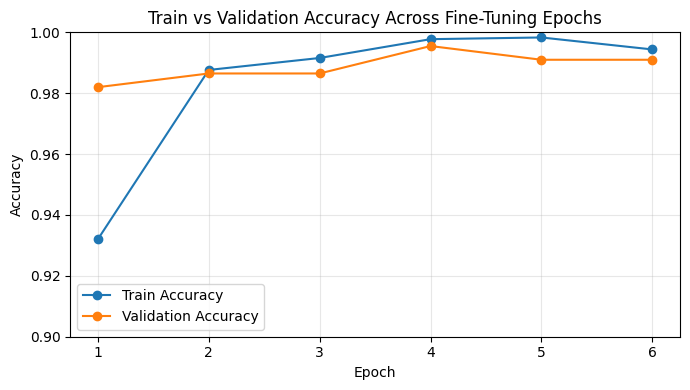

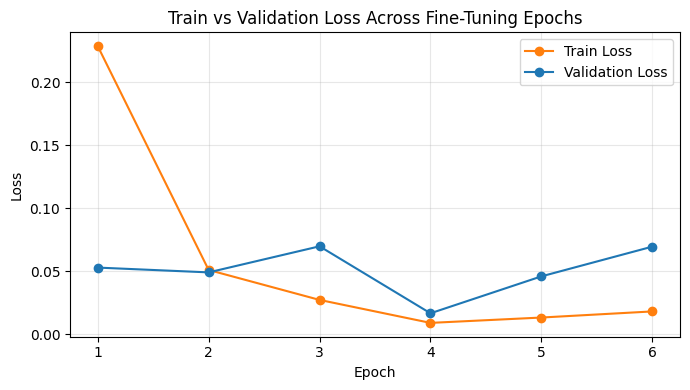

In [10]:
# Accuracy/loss visualization for the training cell
epochs = list(range(1, len(train_acc_history) + 1))

plt.figure(figsize=(7, 4))
plt.plot(epochs, train_acc_history, marker="o", label="Train Accuracy")
plt.plot(epochs, val_acc_history, marker="o", label="Validation Accuracy")
plt.ylim(0.9, 1.0)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Validation Accuracy Across Fine-Tuning Epochs")
plt.xticks(epochs)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(epochs, train_loss_history, marker="o", color="#ff7f0e", label="Train Loss")
plt.plot(epochs, val_loss_history, marker="o", color="#1f77b4", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss Across Fine-Tuning Epochs")
plt.xticks(epochs)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

BBC test loss (best fine-tuned model): 0.0886
BBC test accuracy (best fine-tuned model): 0.9865

Classification report (test only):
               precision    recall  f1-score   support

     business     1.0000    0.9412    0.9697        51
entertainment     1.0000    1.0000    1.0000        39
     politics     0.9333    1.0000    0.9655        42
        sport     1.0000    1.0000    1.0000        51
         tech     1.0000    1.0000    1.0000        40

     accuracy                         0.9865       223
    macro avg     0.9867    0.9882    0.9870       223
 weighted avg     0.9874    0.9865    0.9866       223


Probabilities shape: (223, 5)
First sample probabilities: [2.6757942e-04 8.7446184e-05 9.9942148e-01 1.0660733e-04 1.1690472e-04]


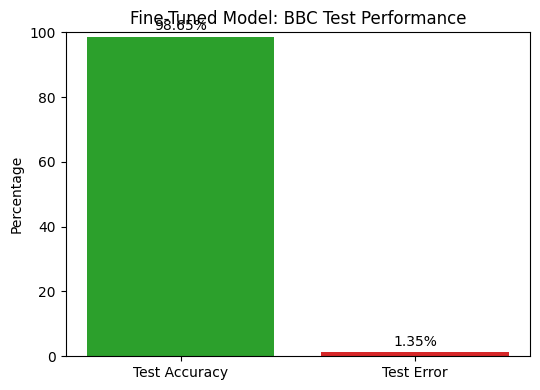

In [11]:
# Final test evaluation after fine-tuning + test accuracy visualization
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# Rebuild test loader for BBC test split only (prompted format)
test_loader = build_loader(prompted_tokenized_datasets, "test", batch_size=batch_size, shuffle=False)

# Evaluate best fine-tuned model on test split
test_loss, test_acc_ids, all_true_ids, all_pred_ids = evaluate_loss_and_accuracy(model, test_loader, criterion, device)
y_true = [id2label[int(i)] for i in all_true_ids]
y_pred = [id2label[int(i)] for i in all_pred_ids]
acc = test_acc_ids

print(f"BBC test loss (best fine-tuned model): {test_loss:.4f}")
print(f"BBC test accuracy (best fine-tuned model): {acc:.4f}")
print("\nClassification report (test only):")
print(classification_report(y_true, y_pred, labels=LABELS, digits=4))

# Softmax probabilities on test split
all_probs = []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        token_type_ids = batch.get("token_type_ids")
        if token_type_ids is not None:
            token_type_ids = token_type_ids.to(device)

        logits = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
        )
        probs = torch.softmax(logits, dim=-1)
        all_probs.append(probs.cpu())

all_probs = torch.cat(all_probs, dim=0).numpy()
print("\nProbabilities shape:", all_probs.shape)
print("First sample probabilities:", all_probs[0])

# Accuracy visualization for the final test cell
plt.figure(figsize=(5.5, 4))
bars = plt.bar(["Test Accuracy", "Test Error"], [acc * 100.0, (1.0 - acc) * 100.0], color=["#2ca02c", "#d62728"])
plt.ylim(0, 100)
plt.ylabel("Percentage")
plt.title("Fine-Tuned Model: BBC Test Performance")
for bar, value in zip(bars, [acc * 100.0, (1.0 - acc) * 100.0]):
    plt.text(bar.get_x() + bar.get_width() / 2, value + 1, f"{value:.2f}%", ha="center", va="bottom")
plt.tight_layout()
plt.show()

In [13]:
# Save fine-tuned BERT classifier weights to the project `models` folder (run after the training cell).
models_dir = Path("../models").resolve()
models_dir.mkdir(parents=True, exist_ok=True)
out_path = models_dir / "bbc_bert_base_tuned.pt"
torch.save(model.state_dict(), out_path)
print(f"Saved model state dict to {out_path}")

Saved model state dict to D:\llm_doc_classification\models\bbc_bert_base_tuned.pt
